# Evaluate Dataset Coverage

This notebook loads dataset CSV files from a folder and plots `qvel` vs `qtorque_cmd`.

For the current PD datasets, `qact` is the target position. Use `qtorque_cmd` as the torque-like command for coverage and system-identification checks.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Configuration

Set `DATASET_DIR` to the folder containing current PD dataset CSV files. The notebook plots only files that contain `qtorque_cmd`; older files without this column are skipped.

In [2]:
MOTOR_NAME = "test_motor"

In [3]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "scripts" else Path.cwd()
DATASET_DIR = PROJECT_ROOT / "data" / MOTOR_NAME

BASE_COLUMNS = {"time_s", "qpos", "qvel"}
TORQUE_COLUMN = "qtorque_cmd"
POINT_ALPHA = 0.35
POINT_SIZE = 8

In [4]:
def load_dataset_folder(dataset_dir: Path = DATASET_DIR) -> dict[str, pd.DataFrame]:
    csv_paths = sorted(dataset_dir.glob("*.csv"))
    if not csv_paths:
        raise FileNotFoundError(f"No CSV files found in {dataset_dir}")

    datasets = {}
    skipped = []
    for path in csv_paths:
        df = pd.read_csv(path)
        if TORQUE_COLUMN not in df.columns:
            skipped.append(path.name)
            continue

        missing = BASE_COLUMNS - set(df.columns)
        if missing:
            raise ValueError(f"{path} is missing required columns: {sorted(missing)}")
        datasets[path.stem] = df

    if not datasets:
        raise ValueError(f"No CSV files with {TORQUE_COLUMN!r} found in {dataset_dir}")
    if skipped:
        print(f"Skipped {len(skipped)} files without {TORQUE_COLUMN}: {skipped}")
    return datasets


datasets = load_dataset_folder()
print(f"Loaded {len(datasets)} dataset files with {TORQUE_COLUMN} from {DATASET_DIR}")

summary = pd.DataFrame(
    [
        {
            "run": name,
            "samples": len(df),
            "duration_s": df["time_s"].iloc[-1] - df["time_s"].iloc[0],
            "qvel_min": df["qvel"].min(),
            "qvel_max": df["qvel"].max(),
            "qtorque_cmd_min": df[TORQUE_COLUMN].min(),
            "qtorque_cmd_max": df[TORQUE_COLUMN].max(),
        }
        for name, df in datasets.items()
    ]
)
summary

Loaded 13 dataset files with qtorque_cmd from /home/tndrd/Projects/encos-sys-id/data/test_motor


,run,samples,duration_s,qvel_min,qvel_max,qtorque_cmd_min,qtorque_cmd_max
0,pd_chirp_qpos_amp0p4_0p1_1p5hz_kp8_kd1,10000,9.999,-5.001221,4.649572,-9.577836,10.426802
1,pd_chirp_qpos_amp0p4_0p1_2hz_kp10_kd1,12000,11.999,-5.421246,5.401709,-11.903159,12.004331
2,pd_chirp_qpos_amp0p5_0p1_1p5hz_kp30_kd1p5,10000,9.999,-7.316239,7.833944,-34.549171,21.812419
3,pd_chirp_qpos_amp0p6_0p1_2hz_kp10_kd1,12000,11.999,-7.316239,7.404152,-22.929525,21.463880
4,pd_linear_qpos_0_to_1p6_8s_kp20_kd0p8,8000,7.999,-0.019537,0.322344,0.160000,11.128065
5,pd_pulses_qpos_amp0p4_150ms_800ms_s3_kp30_kd3,10000,9.999,-2.256411,1.465202,-11.557614,10.149279
6,pd_pulses_qpos_amp1p0_400ms_800ms_s3_kp20_kd1,10000,9.999,-7.247863,5.147741,-22.570686,19.959037
7,pd_sine_qpos_amp0p5_0p25hz_kp6_kd0p8,8000,7.999,-0.654457,0.732601,-3.029463,2.987222
8,pd_sine_qpos_amp1p6_0p5hz_kp20_kd1,5000,4.999,-5.567765,5.460318,-10.660479,12.852263
9,pd_steps_qpos_amp1p0_800ms_s9_kp25_kd0p8,10000,9.999,-9.699634,7.658119,-38.235342,17.680832


In [5]:
all_data = pd.concat(
    [df.assign(dataset=name) for name, df in datasets.items()],
    ignore_index=True,
)

FIGURE_DIR = PROJECT_ROOT / "img" #Path("/home/slava/projects/papers/Dissertation/images")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

QVEL_LABEL = r"Угловая скорость вала привода $\dot q$, рад/с"
TORQUE_LABEL = r"Расчетная команда момента $u_\tau$, Н·м"


def save_dissertation_figure(fig, stem: str) -> None:
    fig.savefig(FIGURE_DIR / f"{stem}.pdf", bbox_inches="tight", facecolor="white")
    fig.savefig(FIGURE_DIR / f"{stem}.png", dpi=300, bbox_inches="tight", facecolor="white")


def _val(token: str, prefix: str = "") -> str:
    return token.removeprefix(prefix).replace("p", ".")


def trajectory_group(name: str) -> str | None:
    if "chirp" in name:
        return "а) Чирп-сигналы"
    if "pulses" in name:
        return "б) Импульсные воздействия"
    if "steps" in name:
        return "в) Ступенчатые воздействия"
    return None


def trajectory_title(name: str) -> str:
    parts = name.split("_")
    amp = next((_val(p, "amp") for p in parts if p.startswith("amp")), None)
    kp = next((_val(p, "kp") for p in parts if p.startswith("kp")), None)
    kd = next((_val(p, "kd") for p in parts if p.startswith("kd")), None)
    fields = [f"A={amp}" if amp else None, f"kp={kp}" if kp else None, f"kd={kd}" if kd else None]
    return "; ".join(x for x in fields if x)


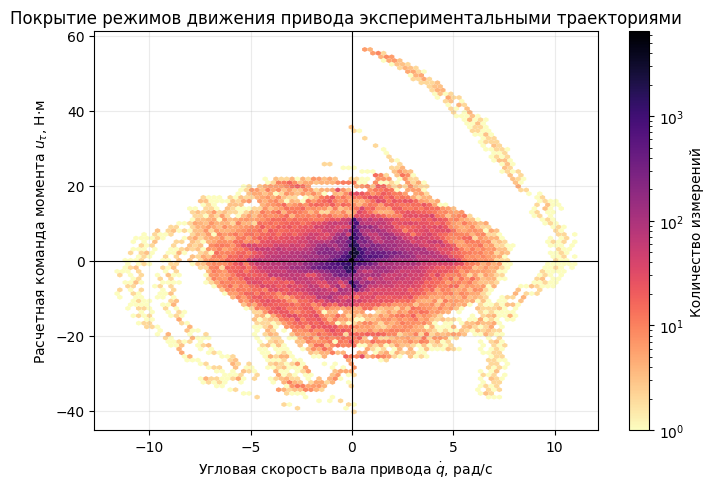

In [6]:
fig, ax = plt.subplots(figsize=(7.2, 5.0))
h = ax.hexbin(
    all_data["qvel"],
    all_data[TORQUE_COLUMN],
    gridsize=85,
    mincnt=1,
    bins="log",
    cmap="magma_r",
    linewidths=0,
)
ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel(QVEL_LABEL)
ax.set_ylabel(TORQUE_LABEL)
ax.set_title("Покрытие режимов движения привода экспериментальными траекториями")
ax.grid(alpha=0.25)
fig.colorbar(h, ax=ax, label="Количество измерений")
fig.tight_layout()
save_dissertation_figure(fig, "history_dataset_regime_coverage")


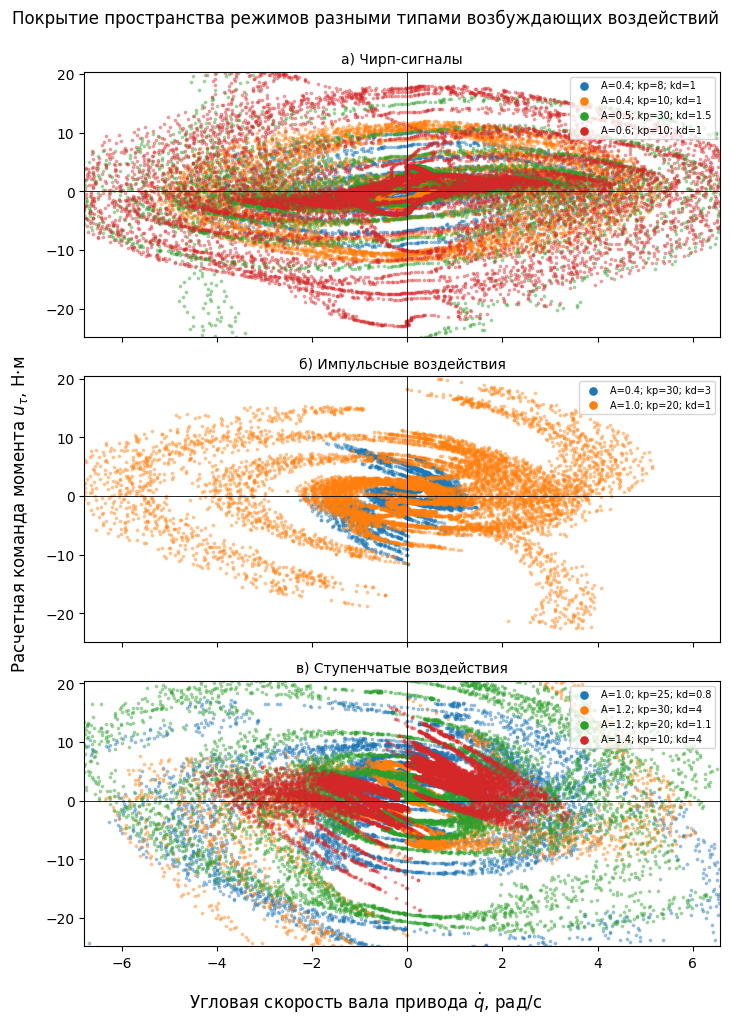

In [7]:
groups = ["а) Чирп-сигналы", "б) Импульсные воздействия", "в) Ступенчатые воздействия"]
grouped = {
    group: [(name, df) for name, df in datasets.items() if trajectory_group(name) == group]
    for group in groups
}
xlim = all_data["qvel"].quantile([0.005, 0.995]).to_numpy()
ylim = all_data[TORQUE_COLUMN].quantile([0.005, 0.995]).to_numpy()

fig, axes = plt.subplots(3, 1, figsize=(7.4, 10.2), sharex=True, sharey=True)

for ax, group in zip(axes, groups):
    for idx, (name, df) in enumerate(grouped[group]):
        ax.scatter(
            df["qvel"],
            df[TORQUE_COLUMN],
            s=3,
            alpha=0.35,
            color=f"C{idx}",
            label=trajectory_title(name),
            rasterized=True,
        )
    ax.axhline(0, color="black", linewidth=0.6)
    ax.axvline(0, color="black", linewidth=0.6)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_title(group, fontsize=10)
    legend = ax.legend(fontsize=7, loc="upper right", frameon=True, markerscale=3)
    for handle in legend.legend_handles:
        handle.set_alpha(1.0)

fig.supxlabel(QVEL_LABEL)
fig.supylabel(TORQUE_LABEL)
fig.suptitle("Покрытие пространства режимов разными типами возбуждающих воздействий", y=0.995)
fig.tight_layout()
save_dissertation_figure(fig, "history_dataset_excitation_families")


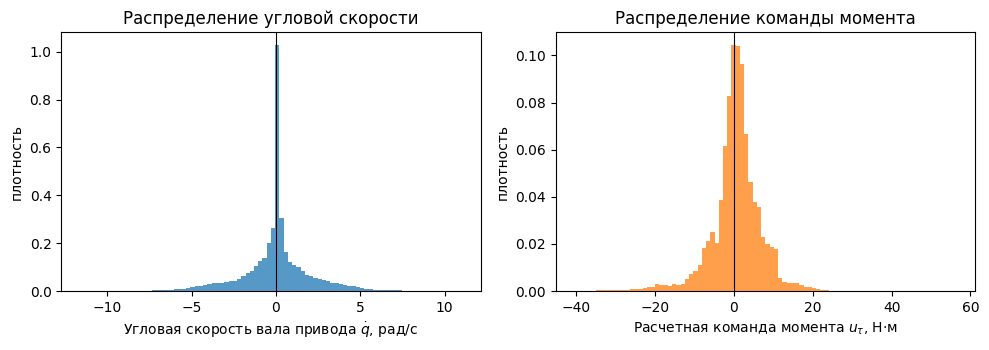

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))

axes[0].hist(all_data["qvel"], bins=90, density=True, color="tab:blue", alpha=0.75)
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_xlabel(QVEL_LABEL)
axes[0].set_ylabel("плотность")
axes[0].set_title("Распределение угловой скорости")

axes[1].hist(all_data[TORQUE_COLUMN], bins=90, density=True, color="tab:orange", alpha=0.75)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_xlabel(TORQUE_LABEL)
axes[1].set_ylabel("плотность")
axes[1].set_title("Распределение команды момента")

fig.tight_layout()
save_dissertation_figure(fig, "history_dataset_marginal_distributions")


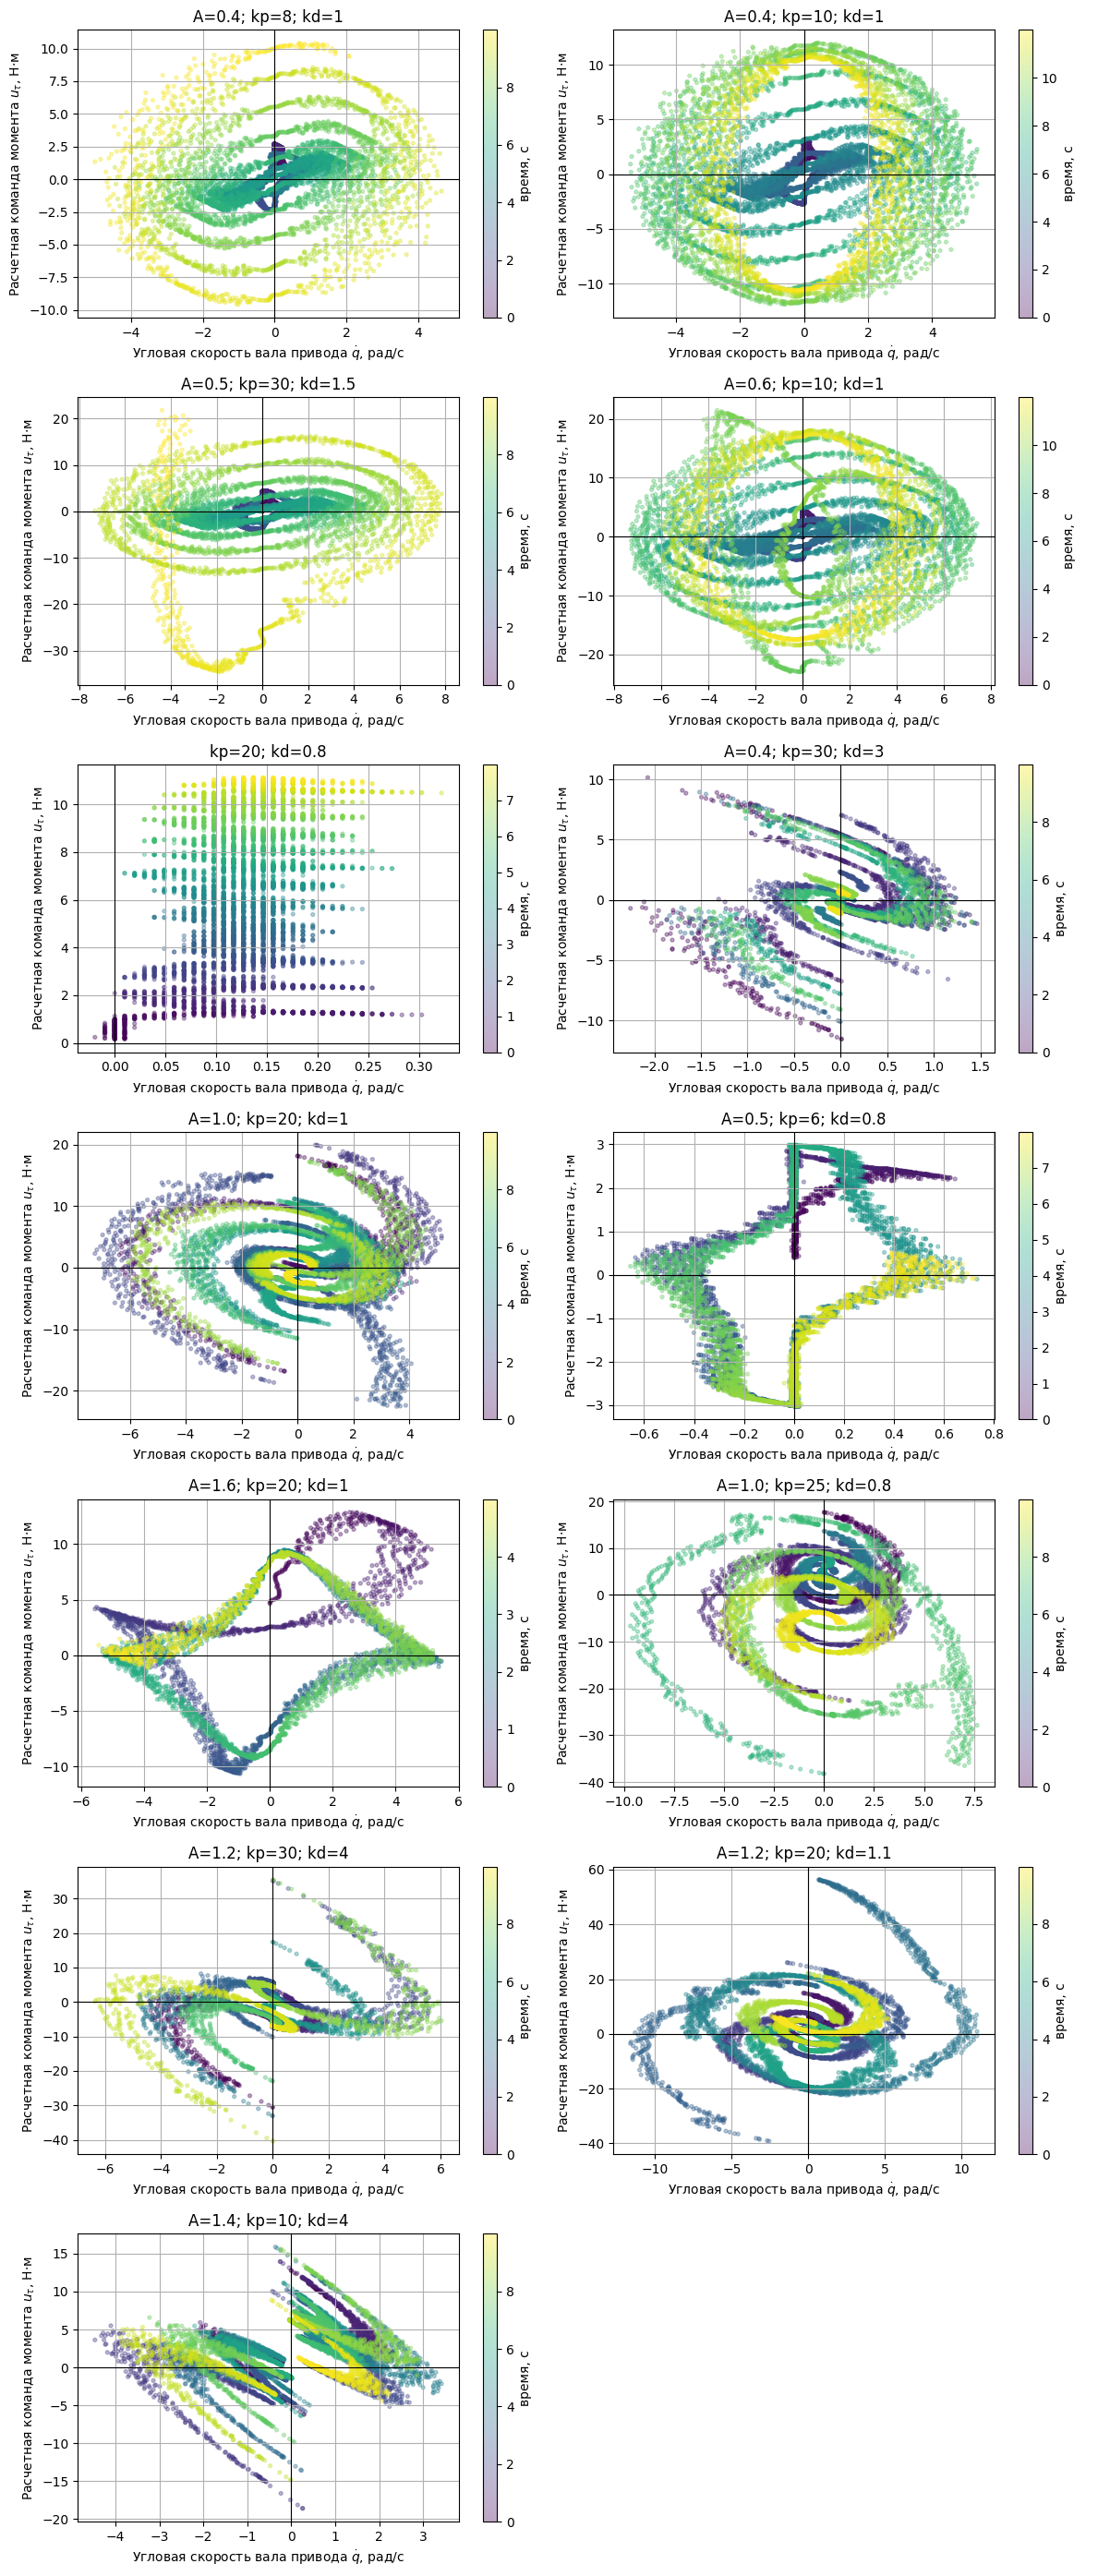

In [9]:
cols = 2
rows = int(np.ceil(len(datasets) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows), squeeze=False)

for axis, (name, df) in zip(axes.ravel(), datasets.items()):
    scatter = axis.scatter(
        df["qvel"],
        df["qtorque_cmd"],
        c=df["time_s"],
        cmap="viridis",
        s=POINT_SIZE,
        alpha=POINT_ALPHA,
    )
    axis.axhline(0, color="black", linewidth=0.8)
    axis.axvline(0, color="black", linewidth=0.8)
    axis.set_title(trajectory_title(name) or name)
    axis.set_xlabel(QVEL_LABEL)
    axis.set_ylabel(TORQUE_LABEL)
    axis.grid()
    fig.colorbar(scatter, ax=axis, label="время, с")

for axis in axes.ravel()[len(datasets):]:
    axis.axis("off")

plt.tight_layout()
plt.show()